# PD Example
This is demo of Partial Dependence (Plots).

# Virtual Environment and Dependencies
Prepare and activate virtual environment with MLI-2 dependencies. Import dependencies:

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
from mli.explanation.pd import PD

## Dataset
Simple dataset with numerical and categorical features:

In [2]:
X = pd.DataFrame({
    'f1': [1, 2, 3, 4, 5, 6, 2, 2, 3, 4, 5, 6, 1, 2, 3, 4, 5, 3],
    'f2': ['cat', 'dog', 'cat9', 'sheep', 'cat5', 'dog4', 'cat1', 'dog',
          'cat1', '1sheep', '2cat', '1dog', '3cat', '2dog', 'cat',
          'sheep5', 'cat', 'dog8'],
    'f3': [50, 40, 30, 20, 10, 0, 48, 45, 35, 25, 15, 3, 50, 40, 30, 20, 10, 0]})

print(X)

    f1      f2  f3
0    1     cat  50
1    2     dog  40
2    3    cat9  30
3    4   sheep  20
4    5    cat5  10
5    6    dog4   0
6    2    cat1  48
7    2     dog  45
8    3    cat1  35
9    4  1sheep  25
10   5    2cat  15
11   6    1dog   3
12   1    3cat  50
13   2    2dog  40
14   3     cat  30
15   4  sheep5  20
16   5     cat  10
17   3    dog8   0


## Regression Examples
Foo predict methods for regression without any dependencies just for demonstration purposes - note method signature with exactly one input parameter (dataset) and Pandas DataFrame return value with 1 column:

In [3]:
# regression predict method returns 1 column
def regression(x):
    return (x['f1']+x['f3'])/100

Compute PD explanations for feature `f1`:


'f1':
 'p_0':
      1.000000  1.555556  2.111111  2.666667  3.222222  3.777778  4.333333  \
mean  0.271667  0.277222  0.282778  0.288333  0.293889  0.299444  0.305000   
sd    0.173010  0.173010  0.173010  0.173010  0.173010  0.173010  0.173010   
sem   0.040779  0.040779  0.040779  0.040779  0.040779  0.040779  0.040779   

      4.888889  5.444444  6.000000  
mean  0.310556  0.316111  0.321667  
sd    0.173010  0.173010  0.173010  
sem   0.040779  0.040779  0.040779  



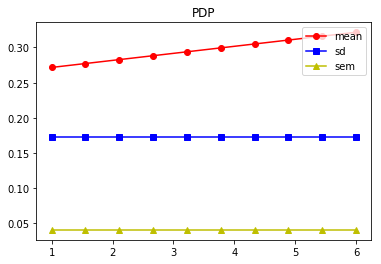

In [4]:
pdp = PD("PD").explain(['f1'], X, predict_method=regression)

print(pdp)
pdp.explanations()['f1']['p_0'].transpose().plot(kind='line', style=['ro-', 'bs-', 'y^-'], title="PDP")
plt.show()

Calculate PD explanations for given **bins**:

In [5]:
es = PD("PD w/ bins").explain(['f1'], X, predict_method=regression, bins=[[1, 10]]).explanations()
print(es['f1']['p_0'])

            1         10
mean  0.271667  0.361667
sd    0.173010  0.173010
sem   0.040779  0.040779


Calculate and **center** PD explanations:

In [6]:
pdp = PD("PD w/ bins").explain(['f1'], X, predict_method=regression, bins=[[1, 10]], center=True)
print(pdp.explanations()['f1']['p_0'])

            1         10
mean -0.045000  0.045000
sd    0.173010  0.173010
sem   0.040779  0.040779


Calculate PD explanations for **multiple features** and given bins:

In [7]:
pdp = PD("PD").explain(['f1','f3'], X, predict_method=regression, bins=[[1,2],[5,6,7]])
print(pdp)


'f1':
 'p_0':
             1         2
mean  0.271667  0.281667
sd    0.173010  0.173010
sem   0.040779  0.040779
'f3':
 'p_0':
             5         6         7
mean  0.083889  0.093889  0.103889
sd    0.015770  0.015770  0.015770
sem   0.003717  0.003717  0.003717



Calculate PD explanations for **residuals** and use `average` as transformation function:

In [8]:
pdp = PD("PD for residuals")

# actual values
Y = pd.DataFrame({'actual values': [1, 2, 3, 4, 5, 6, 1, 2, 3, 4, 5, 6, 1, 2, 3, 4, 5, 3]})

pdp.explain(['f1'], X, Y=Y, target_transform=abs, predict_method=regression, bins=[[5, 10, 15]])
print(pdp.explanations()['f1']['p_0'])

                      5         10        15
mean            0.311667  0.361667  0.411667
sd              0.173010  0.173010  0.173010
sem             0.040779  0.040779  0.040779
residuals_mean  3.021667  2.971667  2.921667
residuals_sd    1.801778  1.801778  1.801778
residuals_sem   0.424683  0.424683  0.424683


Calculate **out of range** PDs for 2x standard deviations (below and above):


'f1':
 'p_0':
       1.000000   1.555556   2.111111   2.666667   3.222222   3.777778  \
mean   0.271667   0.277222   0.282778   0.288333   0.293889   0.299444   
sd     0.173010   0.173010   0.173010   0.173010   0.173010   0.173010   
sem    0.040779   0.040779   0.040779   0.040779   0.040779   0.040779   

       4.333333   4.888889   5.444444   6.000000  -0.577000  -2.153999  \
mean   0.305000   0.310556   0.316111   0.321667   0.255897   0.240127   
sd     0.173010   0.173010   0.173010   0.173010   0.173010   0.173010   
sem    0.040779   0.040779   0.040779   0.040779   0.040779   0.040779   

       7.577000   9.153999  
mean   0.337437   0.353207  
sd     0.173010   0.173010  
sem    0.040779   0.040779  



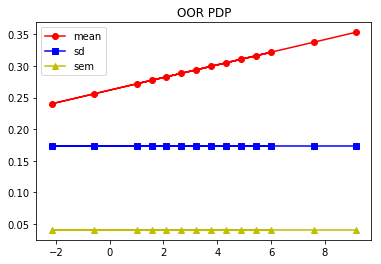

In [9]:
pdp = PD("Out of range PDs")
pdp.explain(['f1'], X, out_of_range_resolution=2, predict_method=regression)

print(pdp)
pdp.explanations()['f1']['p_0'].transpose().plot(kind='line', style=['ro-', 'bs-', 'y^-'], title="OOR PDP")
plt.show()

Calculate PD for **categorical** feature (10 most **frequent** is chosen by default):

In [10]:
pdp = PD("Cat feature PD").explain(['f2'], X, predict_method=regression)
print(pdp)


'f2':
 'p_0':
           cat       dog      cat1    sheep5     sheep      dog8      dog4  \
mean  0.295556  0.295556  0.295556  0.295556  0.295556  0.295556  0.295556   
sd    0.159160  0.159160  0.159160  0.159160  0.159160  0.159160  0.159160   
sem   0.037514  0.037514  0.037514  0.037514  0.037514  0.037514  0.037514   

          cat9      cat5      3cat  
mean  0.295556  0.295556  0.295556  
sd    0.159160  0.159160  0.159160  
sem   0.037514  0.037514  0.037514  



**Indicate** that feature is categorical (regardless there are numerical values) - note that values are ordered by **frequency**:

In [11]:
pdp = PD('Cat PD').explain(['f1'], X, predict_method=regression, features_meta = {'categorical': ['f1']})
print(pdp)


'f1':
 'p_0':
             3         2         5         4         6         1
mean  0.291667  0.281667  0.311667  0.301667  0.321667  0.271667
sd    0.173010  0.173010  0.173010  0.173010  0.173010  0.173010
sem   0.040779  0.040779  0.040779  0.040779  0.040779  0.040779



Indicate that **bins** for feature should be calculated as **quantiles**:

In [12]:
pdp = PD('Cat PD').explain(['f3'], X, predict_method=regression, features_meta = {'quantile-bin': ['f3']})
print(pdp)


'f3':
 'p_0':
          2.1       10.0      15.5      20.0      27.5      31.0      39.5  \
mean  0.054889  0.133889  0.188889  0.233889  0.308889  0.343889  0.428889   
sd    0.015770  0.015770  0.015770  0.015770  0.015770  0.015770  0.015770   
sem   0.003717  0.003717  0.003717  0.003717  0.003717  0.003717  0.003717   

          43.0      48.6      50.0  
mean  0.463889  0.519889  0.533889  
sd    0.015770  0.015770  0.015770  
sem   0.003717  0.003717  0.003717  



# Multinomial Classification Examples
Foo predict method for multinomial classification without any dependencies just for demonstration purposes - note method signature with exactly one input parameter (dataset) and Pandas DataFrame return value with more than 2 columns:

In [13]:
# multinomial classification predict method returns >2 columns
def multiclass(x):
    c1 = (X['f1']+X['f3'])/100
    c2 = abs((X['f1']-X['f3'])/100)
    c3 = 1-(c1+c2)
    return pd.DataFrame({'c1':c1, 'c2':c2, 'c3':c3})

Compute **multinomial** classification PD explanations for feature `f1`:


'f1':
 'p_0':
      1.000000  1.555556  2.111111  2.666667  3.222222  3.777778  4.333333  \
mean  0.271667  0.277222  0.282778  0.288333  0.293889  0.299444  0.305000   
sd    0.173010  0.173010  0.173010  0.173010  0.173010  0.173010  0.173010   
sem   0.040779  0.040779  0.040779  0.040779  0.040779  0.040779  0.040779   

      4.888889  5.444444  6.000000  
mean  0.310556  0.316111  0.321667  
sd    0.173010  0.173010  0.173010  
sem   0.040779  0.040779  0.040779  
 'p_1':
      1.000000  1.555556  2.111111  2.666667  3.222222  3.777778  4.333333  \
mean  0.253889  0.249568  0.245247  0.240926  0.236852  0.233148  0.229444   
sd    0.169537  0.167685  0.165889  0.164153  0.162096  0.159536  0.157049   
sem   0.039960  0.039524  0.039100  0.038691  0.038206  0.037603  0.037017   

      4.888889  5.444444  6.000000  
mean  0.225741  0.222037  0.218333  
sd    0.154640  0.152312  0.150069  
sem   0.036449  0.035900  0.035372  
 'p_2':
      1.000000  1.555556  2.111111  2.666667  3

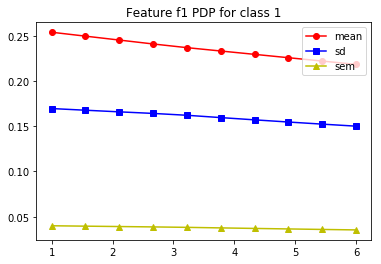

In [14]:
pdp = PD("PD").explain(['f1'], X, predict_method=multiclass)

print(pdp)
pdp.explanations()['f1']['p_1'].transpose().plot(
    kind='line', style=['ro-', 'bs-', 'y^-'], title="Feature f1 PDP for class 1")
plt.show()

Calculate PD explanations for **residuals** of multiclass prediction and use `avg` as transformation function. 
Note that the number `Y` of columns **must** correspond to the number of columns returned by predict method.

In [15]:
pdp = PD("PD for residuals")

# actual values
Y = pd.DataFrame({
    'actual values for class A': [1, 2, 3, 4, 5, 6, 1, 2, 3, 4, 5, 6, 1, 2, 3, 4, 5, 3],
    'actual values for class B': [10, 20, 30, 40, 50, 60, 10, 20, 30, 40, 50, 60, 10, 20, 30, 40, 50, 30],
    'actual values for class C': [.1, .2, .3, .4, .5, .6, .1, .2, .3, .4, .5, .6, .1, .2, .3, .4, .5, .3]
})

pdp.explain(['f1'], X, Y=Y, target_transform=abs, predict_method=multiclass, bins=[[5, 10, 15]])
print(pdp)


'f1':
 'p_0':
                      5         10        15
mean            0.311667  0.361667  0.411667
sd              0.173010  0.173010  0.173010
sem             0.040779  0.040779  0.040779
residuals_mean  3.021667  2.971667  2.921667
residuals_sd    1.801778  1.801778  1.801778
residuals_sem   0.424683  0.424683  0.424683
 'p_1':
                       5          10         15
mean             0.225000   0.191667   0.169444
sd               0.154168   0.136780   0.112849
sem              0.036338   0.032239   0.026599
residuals_mean  33.108333  33.141667  33.163889
residuals_sd    16.592706  16.574818  16.545036
residuals_sem    3.910938   3.906722   3.899702
 'p_2':
                      5         10        15
mean            0.463333  0.446667  0.418889
sd              0.326064  0.303935  0.271508
sem             0.076854  0.071638  0.063995
residuals_mean  0.170000  0.153333  0.125556
residuals_sd    0.150176  0.126119  0.096967
residuals_sem   0.035397  0.029726  0.022855



# Multi-dimensional PD examples

Calculate **multi-dimensional** PD for multiple features.

In [16]:
pd = PD("m-PD").explain(
    [('f1','f2'),'f1'], 
    X, 
    predict_method=regression, 
    bins=[([1,2],[30,40,50]),[7,8]])

print(pd)


'('f1', 'f2')':
 'p_0':
       (1, 30)   (1, 40)   (1, 50)   (2, 30)   (2, 40)   (2, 50)
mean  0.271667  0.271667  0.271667  0.281667  0.281667  0.281667
sd    0.173010  0.173010  0.173010  0.173010  0.173010  0.173010
sem   0.040779  0.040779  0.040779  0.040779  0.040779  0.040779
'f1':
 'p_0':
             7         8
mean  0.331667  0.341667
sd    0.173010  0.173010
sem   0.040779  0.040779



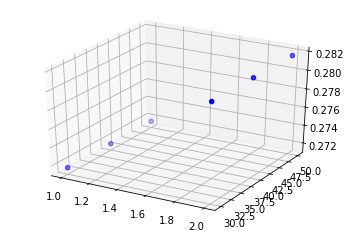

In [17]:
x = []
y = []
z = []
df = pd.explanations()[('f1','f2')]['p_0']
for c in df.columns.values:
    x.append(c[0])
    y.append(c[1])
    z.append(df.iloc[0][c])

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c='b', marker='o')
plt.show()